In [1]:
%matplotlib inline
import os
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.special import gamma #special function for rescaling tau
import pandas as pd
from scipy.special import gamma


In [19]:
import numpy as np #numerical python used for working with arrays, mathematical operations
import xarray as xr #package for labeling and adding metadata to multi-dimensional arrays

In [20]:


import os
import pandas as pd
import xarray as xr

# Step 1: Specify the folder containing the CSV files
folder_path = "C:\\Users\\renit\\Desktop\\test"

# Step 2: Loop through each file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):  # Process only CSV files
        csv_file_path = os.path.join(folder_path, filename)

        # Step 3: Read CSV file into a pandas DataFrame
        df = pd.read_csv(csv_file_path)

        # Step 4: Convert DataFrame to xarray Dataset
        ds = xr.Dataset.from_dataframe(df)

        # Step 5: Save the Dataset as a NetCDF file
        netcdf_file_path = os.path.join(folder_path, filename.replace('.csv', '.nc'))
        ds.to_netcdf(netcdf_file_path)

        print(f"Converted {filename} to {filename.replace('.csv', '.nc')}")

print("All CSV files have been successfully converted to NetCDF files!")


All CSV files have been successfully converted to NetCDF files!


In [21]:


# Step 1: Specify the folder containing the .nc files
folder_path = "C:\\Users\\renit\\Desktop\\test"

# Step 2: Loop through each .nc file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.nc'):  # Process only .nc files
        nc_file_path = os.path.join(folder_path, filename)

        # Step 3: Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Step 4: Process the ddm_fit_data for each file (for now, just print filename)
        print(f"Processing file: {filename}")
        print(ddm_fit_data)  # You can replace this with any operation you want to perform on each dataset

        


print("All NetCDF files in the folder have been processed!")


Processing file: vn3-2.nc
<xarray.Dataset>
Dimensions:          (parameter: 2, q: 128, lagtime: 10)
Coordinates:
  * parameter        (parameter) object 'Tau' 'StretchingExp'
  * q                (q) float64 0.0 0.1411 0.2821 0.4232 ... 17.63 17.77 17.91
  * lagtime          (lagtime) float64 0.1992 0.3985 0.797 ... 28.69 58.58 119.5
Data variables:
    parameters       (parameter, q) float64 0.02835 1e+04 1.136e+03 ... 0.5 0.5
    theory           (lagtime, q) float64 2.49e-07 1.0 1.0 ... 0.083 0.1924
    isf_data         (lagtime, q) float64 0.0 1.0 1.0 1.0 ... 0.5597 0.5202 0.59
    ddm_matrix_data  (lagtime, q) float64 0.0 26.88 29.08 ... 31.12 31.21 31.1
    A                (q) float64 -30.55 2.728e+05 2.2e+04 ... 1.303 1.379 1.342
    B                float64 30.55
Attributes: (12/18)
    model:                          ISF - Single Exponential
    data_to_use:                    ISF
    initial_params_dict:            ["{'n': 0, 'value': 1.0, 'limits': [0.001...
    effective_d

<xarray.Dataset>
Dimensions:          (parameter: 2, q: 128, lagtime: 10)
Coordinates:
  * parameter        (parameter) object 'Tau' 'StretchingExp'
  * q                (q) float64 0.0 0.1411 0.2821 0.4232 ... 17.63 17.77 17.91
  * lagtime          (lagtime) float64 0.1992 0.3985 0.797 ... 28.69 58.58 119.5
Data variables:
    parameters       (parameter, q) float64 0.02835 1e+04 1.136e+03 ... 0.5 0.5
    theory           (lagtime, q) float64 2.49e-07 1.0 1.0 ... 0.083 0.1924
    isf_data         (lagtime, q) float64 0.0 1.0 1.0 1.0 ... 0.5597 0.5202 0.59
    ddm_matrix_data  (lagtime, q) float64 0.0 26.88 29.08 ... 31.12 31.21 31.1
    A                (q) float64 -30.55 2.728e+05 2.2e+04 ... 1.303 1.379 1.342
    B                float64 30.55
Attributes: (12/18)
    model:                          ISF - Single Exponential
    data_to_use:                    ISF
    initial_params_dict:            ["{'n': 0, 'value': 1.0, 'limits': [0.001...
    effective_diffusion_coeff:      0.003

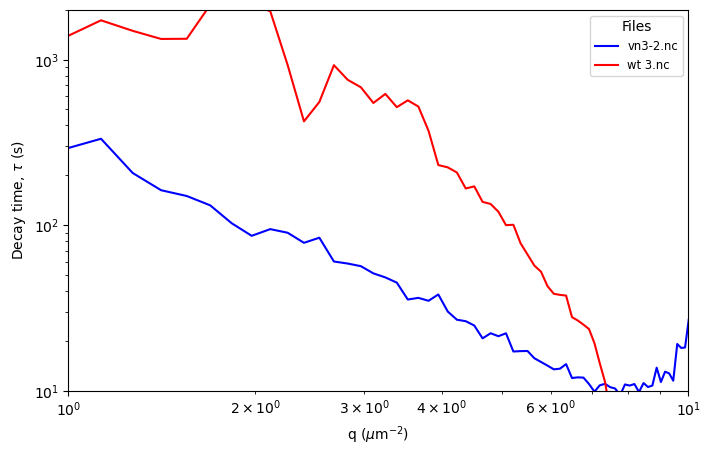

Combined plot saved as combined_decay_time_vs_q.png.


In [24]:
#decay time vs tau plots
# Step 1: Specify the folder containing the .nc files
folder_path = "C:\\Users\\renit\\Desktop\\test"

# Create a figure for the combined plot
fig_combined, ax_combined = plt.subplots(figsize=(8, 8 / 1.618))

# Step 2: Loop through each .nc file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.nc'):  # Process only .nc files
        nc_file_path = os.path.join(folder_path, filename)

        # Step 3: Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Print the dataset structure to explore its contents
        print(ddm_fit_data)


        # Step 4: Extract Tau and q values based on the 'parameter' variable
        #tau = ddm_fit_data.parameters.where(ddm_fit_data.parameter == 'Tau', drop=True)
        
        #q_values = ddm_fit_data.q.where(ddm_fit_data.parameter == 'Tau', drop=True)
        #q_values = ddm_fit_data.q

         # Extract 'Tau' (decay time) and 'q' values
        tau = ddm_fit_data.parameters.loc['Tau']
        q_values = ddm_fit_data.q


       

        # Step 5: Determine color based on filename
        if 'wt' in filename:
            color = 'red'
        elif 'vn' in filename:
            color = 'blue'
        else:
            color = 'black'  # Default color if neither 'wt' nor 'vn' is found

        # Create a new figure for individual plots
        fig_individual, ax_individual = plt.subplots(figsize=(8, 8 / 1.618))

        # Plot Tau vs q for each file on the individual plot
        ax_individual.loglog(q_values, tau, label=filename, color=color)
        ax_individual.set_xlim(1, 10)
        ax_individual.set_ylim(10, 2000)
        ax_individual.set_xlabel("q ($\mu$m$^{-2}$)")
        ax_individual.set_ylabel("Decay time, $\\tau$ (s)")
        ax_individual.legend(loc='best', fontsize='small')
        ax_individual.set_title(f"Decay Time vs q for {filename}")

        # Save individual plot as PNG
        individual_plot_filename = f"{filename}_decay_time_vs_q.png"
        plt.savefig(os.path.join(folder_path, individual_plot_filename), dpi=300)
        plt.close(fig_individual)  # Close the figure after saving

        # Plot Tau vs q for the combined plot
        ax_combined.loglog(q_values, tau, label=filename, color=color)

        print(f"Processed and saved individual plot for file: {filename}")

# Customize the combined plot
ax_combined.set_xlim(1, 10)
ax_combined.set_ylim(10, 2000)
ax_combined.set_xlabel("q ($\mu$m$^{-2}$)")
ax_combined.set_ylabel("Decay time, $\\tau$ (s)")
ax_combined.legend(loc='best', fontsize='small', title="Files")  # Add a legend to identify each file

# Save the combined plot
combined_plot_filename = "combined_decay_time_vs_q.png"
plt.savefig(os.path.join(folder_path, combined_plot_filename), dpi=300)

# Show the combined plot
plt.show()

print(f"Combined plot saved as {combined_plot_filename}.")



C:\Users\renit\anaconda33\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
C:\Users\renit\anaconda33\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


File: vn3-2.nc
log_tau values: <xarray.DataArray 'parameters' (q: 34)>
array([6.31775407, 5.66476455, 5.80631408, 5.32970935, 5.09022706,
       5.00963449, 4.8798927 , 4.63014627, 4.45574704, 4.5486089 ,
       4.49830685, 4.35819735, 4.42896919, 4.09810767, 4.06969745,
       4.03301979, 3.9329707 , 3.87664765, 3.80387826, 3.56892093,
       3.59212158, 3.55145105, 3.63916635, 3.40143548, 3.28778978,
       3.26740502, 3.20725309, 3.02860168, 3.09960719, 3.05860657,
       3.09904453, 2.84555524, 2.85087795, 2.85269068])
Coordinates:
    parameter  <U3 'Tau'
  * q          (q) float64 0.8463 0.9874 1.128 1.27 ... 5.078 5.219 5.36 5.501
log_q values: <xarray.DataArray 'q' (q: 34)>
array([-0.16684093, -0.01269025,  0.12084114,  0.23862418,  0.34398469,
        0.43929487,  0.52630625,  0.60634896,  0.68045693,  0.7494498 ,
        0.81398832,  0.87461295,  0.93177136,  0.98583858,  1.03713188,
        1.08592204,  1.13244206,  1.17689382,  1.21945343,  1.26027543,
        1.29949614,  

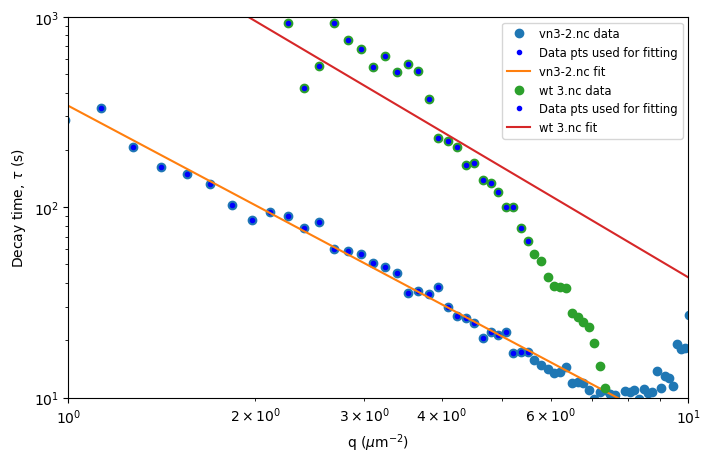

File: vn3-2.nc, Alpha: -1.732, 1/K: 2.937e-03
File: wt 3.nc, Alpha: -1.928, 1/K: 2.764e-04


In [30]:
#Alpha and effective diffusion coefficient values combined plot

# Step 1: Specify the folder containing the .nc files
#folder_path = 'C:\\Users\\renit\\Desktop\\blebb exp2'

# Dictionary to store the alpha and 1/K values for each file
results = {}

# Create a figure for plotting all the fits
fig, ax = plt.subplots(figsize=(8, 8 / 1.618))

# Step 2: Loop through each .nc file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.nc'):  # Process only .nc files
        nc_file_path = os.path.join(folder_path, filename)

        # Step 3: Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Step 4: Extract Tau and q values where parameter == 'Tau'
        #tau = ddm_fit_data.parameters.where(ddm_fit_data.parameter == 'Tau', drop=True)
        #q_values = ddm_fit_data.q.where(ddm_fit_data.parameter == 'Tau', drop=True)

         # Extract 'Tau' (decay time) and 'q' values
        tau = ddm_fit_data.parameters.loc['Tau']
        q_values = ddm_fit_data.q


        # Filter out any NaN or Inf values from the data
        valid_indices = np.isfinite(tau) & np.isfinite(q_values)
        tau = tau[valid_indices]
        q_values = q_values[valid_indices]

        # Step 5: Ensure we have enough valid data points to fit
        qmin_index = 6
        qmax_index = min(40, len(q_values))  # Ensure qmax_index is within bounds

        if len(tau[qmin_index:qmax_index]) < 2 or len(q_values[qmin_index:qmax_index]) < 2:
            print(f"Skipping file {filename} due to insufficient valid data points.")
            continue

        # Step 6: Fitting to a power law
        log_tau = np.log(tau)
        log_q = np.log(q_values)

        # Debug: Print the values of log_tau and log_q
        print(f"File: {filename}")
        print(f"log_tau values: {log_tau[qmin_index:qmax_index]}")
        print(f"log_q values: {log_q[qmin_index:qmax_index]}")

        # Fit to a 1-degree polynomial. Second coefficient will be logK, first will be negative alpha
        try:
            fit_coeff = np.polyfit(log_q[qmin_index:qmax_index], log_tau[qmin_index:qmax_index], 1)
            alpha = fit_coeff[0]
            K = np.exp(fit_coeff[1])
            Deff = 1 / K  # Calculate 1/K

            # Save the results for this file
            results[filename] = {'alpha': alpha, '1/K': Deff}

            # Print results for this file
            print(f"File: {filename} - Found alpha: {alpha:.3f}, 1/K: {Deff:.3e}")

            # Step 7: Plot Tau vs q and the fit
            ax.loglog(q_values, tau, 'o', label=f'{filename} data')
            ax.loglog(q_values[qmin_index:qmax_index], tau[qmin_index:qmax_index], 'b.', label="Data pts used for fitting")

            # Plot the fitted line
            
            fitline_tau = K * q_values**alpha
            ax.loglog(q_values, fitline_tau, '-', label=f'{filename} fit')

        except np.linalg.LinAlgError:
            print(f"LinAlgError in file {filename}: SVD did not converge.")

# Customize the plot
ax.set_xlim(1, 10)
ax.set_ylim(10, 1000)
ax.set_xlabel("q ($\mu$m$^{-2}$)")
ax.set_ylabel("Decay time, $\\tau$ (s)")
ax.legend(loc='best', fontsize='small')

# Show the plot
plt.show()



# Print summary of all results
for file, values in results.items():
    print(f"File: {file}, Alpha: {values['alpha']:.3f}, 1/K: {values['1/K']:.3e}")


In [31]:
# Dictionary to store the alpha and 1/K values for each file
results = []

# Step 2: Loop through each .nc file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.nc'):  # Process only .nc files
        nc_file_path = os.path.join(folder_path, filename)

        # Step 3: Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Step 4: Extract Tau and q values where parameter == 'Tau'
        #tau = ddm_fit_data.parameters.where(ddm_fit_data.parameter == 'Tau', drop=True)
        #q_values = ddm_fit_data.q.where(ddm_fit_data.parameter == 'Tau', drop=True)

         # Extract 'Tau' (decay time) and 'q' values
        tau = ddm_fit_data.parameters.loc['Tau']
        q_values = ddm_fit_data.q


        # Filter out any NaN or Inf values from the data
        valid_indices = np.isfinite(tau) & np.isfinite(q_values)
        tau = tau[valid_indices]
        q_values = q_values[valid_indices]

        # Step 5: Ensure we have enough valid data points to fit
        qmin_index = 60
        qmax_index = min(600, len(q_values))  # Ensure qmax_index is within bounds

        if len(tau[qmin_index:qmax_index]) < 2 or len(q_values[qmin_index:qmax_index]) < 2:
            print(f"Skipping file {filename} due to insufficient valid data points.")
            continue

        # Step 6: Fitting to a power law
        log_tau = np.log(tau)
        log_q = np.log(q_values)

        # Fit to a 1-degree polynomial. Second coefficient will be logK, first will be negative alpha
        try:
            fit_coeff = np.polyfit(log_q[qmin_index:qmax_index], log_tau[qmin_index:qmax_index], 1)
            alpha = fit_coeff[0]
            K = np.exp(fit_coeff[1])
            Deff = 1 / K  # Calculate 1/K

            # Save the results for this file
            results.append({'filename': filename, 'alpha': alpha, '1/K': Deff})

            # Print results for this file
            print(f"File: {filename} - Found alpha: {alpha:.3f}, 1/K: {Deff:.3e}")

            # Step 7: Plot Tau vs q and the fit on a separate graph for each file
            fig, ax = plt.subplots(figsize=(8, 8 / 1.618))

            ax.loglog(q_values, tau, 'o', label=f'{filename} data')
            ax.loglog(q_values[qmin_index:qmax_index], tau[qmin_index:qmax_index], 'b.', label="Data pts used for fitting")

            # Plot the fitted line
            fitline_tau = K * q_values ** alpha
            ax.loglog(q_values, fitline_tau, '-', label=f'{filename} fit')

            # Customize the plot for each file
            ax.set_xlim(1, 10)
            ax.set_ylim(10, 1000)
            ax.set_xlabel("q ($\mu$m$^{-2}$)")
            ax.set_ylabel("Decay time, $\\tau$ (s)")
            ax.legend(loc='best', fontsize='small')

            # Save the individual plot
            plot_filename = f"{filename}_alpha_Deff_plot.png"
            plt.title(f"Fit for {filename}")
            plt.savefig(os.path.join(folder_path, plot_filename), dpi=300)
            plt.close()

            print(f"Plot saved for file: {filename}")

        except np.linalg.LinAlgError:
            print(f"LinAlgError in file {filename}: SVD did not converge.")

# Step 8: Save the alpha and Deff values in a CSV file
results_df = pd.DataFrame(results)
csv_filename = 'alpha_Deff_results.csv'
results_df.to_csv(os.path.join(folder_path, csv_filename), index=False)

# Print summary of all results
for result in results:
    print(f"File: {result['filename']}, Alpha: {result['alpha']:.3f}, 1/K: {result['1/K']:.3e}")

print(f"Results saved in {csv_filename}.")

C:\Users\renit\anaconda33\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


File: vn3-2.nc - Found alpha: 1.854, 1/K: 2.390e+00
Plot saved for file: vn3-2.nc
File: wt 3.nc - Found alpha: -3.783, 1/K: 4.919e-04


C:\Users\renit\anaconda33\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


Plot saved for file: wt 3.nc
File: vn3-2.nc, Alpha: 1.854, 1/K: 2.390e+00
File: wt 3.nc, Alpha: -3.783, 1/K: 4.919e-04
Results saved in alpha_Deff_results.csv.


In [40]:
# Dictionary to store the alpha and 1/K values for each file
results2 = []

# Step 2: Define the function to rescale tau
scaled_tau = lambda t, s: (1. / s) * gamma(1. / s) * t

# Step 3: Loop through each .nc file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.nc'):  # Process only .nc files
        nc_file_path = os.path.join(folder_path, filename)

        # Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Extract 'Tau' (decay time) and 'q' values
        tau = ddm_fit_data.parameters.loc['Tau']
        q_values = ddm_fit_data.q

        # Extract the stretching exponent
        #stretchexp = ddm_fit_data.parameters.where(ddm_fit_data.parameter == 'StretchingExp', drop=True)
        stretchexp = ddm_fit_data.parameters.loc['StretchingExp']

        

        # Check if 'index' exists in the dataset, and only drop if it does
        if 'index' in tau.coords:
            tau = tau.drop('index')
        if 'index' in q_values.coords:
            q_values = q_values.drop('index')
        if 'index' in stretchexp.coords:
            stretchexp = stretchexp.drop('index')

        # Filter out any NaN or Inf values from the data
        valid_indices = np.isfinite(tau) & np.isfinite(q_values)
        tau = tau[valid_indices]
        q_values = q_values[valid_indices]
        stretchexp = stretchexp[valid_indices]

        # Ensure we have enough valid data points to fit
        qmin_index = 60
        qmax_index = min(600, len(q_values))  # Ensure qmax_index is within bounds

        if len(tau[qmin_index:qmax_index]) < 2 or len(q_values[qmin_index:qmax_index]) < 2:
            print(f"Skipping file {filename} due to insufficient valid data points.")
            continue

        # Rescale tau using the stretch exponent
        rescaled_tau = scaled_tau(tau, stretchexp)

        # Step 4: Fitting to a power law with the rescaled tau
        log_tau = np.log(rescaled_tau)
        log_q = np.log(q_values)

        # Ensure both log_tau and log_q have the same length
        if len(log_tau[qmin_index:qmax_index]) != len(log_q[qmin_index:qmax_index]):
            print(f"Skipping file {filename} due to dimension mismatch between log_tau and log_q.")
            continue

        try:
            # Fit to a 1-degree polynomial. Second coefficient will be logK, first will be negative alpha
            fit_coeff = np.polyfit(log_q[qmin_index:qmax_index], log_tau[qmin_index:qmax_index], 1)
            alpha = fit_coeff[0]
            K = np.exp(fit_coeff[1])
            Deff = 1 / K  # Calculate 1/K

            # Save the results for this file
            results2.append({'filename': filename, 'alpha': alpha, '1/K': Deff})

            # Print results for this file
            print(f"File: {filename} - Found alpha: {alpha:.3f}, 1/K: {Deff:.3e}")

            # Step 5: Plot Tau vs q and the fit
            fig, ax = plt.subplots(figsize=(8, 8 / 1.618))
            ax.loglog(q_values, rescaled_tau, 'ro', label=f'{filename} data')
            ax.loglog(q_values[qmin_index:qmax_index], rescaled_tau[qmin_index:qmax_index], 'b.', label="Data pts used for fitting")

            # Plot the fitted line
            fitline_tau = K * q_values ** alpha
            ax.loglog(q_values, fitline_tau, '-k', label=f'{filename} fit')

            # Customize the plot
            ax.set_xlim(1, 10)
            ax.set_ylim(10, 2000)
            ax.set_xlabel("q ($\mu$m$^{-2}$)")
            ax.set_ylabel("Decay time, rescaled based on stretching exponent, $\\tau$ (s)")
            ax.legend(loc='best', fontsize='small')

            # Save the plot instead of showing it
            plot_filename = os.path.join(folder_path, f'rescaled_plot_{filename}.png')
            plt.title(f"Fit for {filename}")
            plt.savefig(plot_filename)

            # Close the plot to avoid memory issues when processing multiple files
            plt.close(fig)

            # Optionally, print the path of the saved plot
            print(f"Plot saved for {filename} as {plot_filename}")

        except np.linalg.LinAlgError:
            print(f"LinAlgError in file {filename}: SVD did not converge.")
            continue

# Step 6: Save the alpha and Deff values in a CSV file
results2_df = pd.DataFrame(results2)
results2_df.to_csv(os.path.join(folder_path, 'rescaled_results.csv'), index=False)

# Print summary of all results
for result in results2:
    print(f"File: {result['filename']}, Alpha: {result['alpha']:.3f}, 1/K: {result['1/K']:.3e}")





C:\Users\renit\anaconda33\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


File: vn3-2.nc - Found alpha: 1.854, 1/K: 1.195e+00
Plot saved for vn3-2.nc as C:\Users\renit\Desktop\test\rescaled_plot_vn3-2.nc.png
File: wt 3.nc - Found alpha: -3.783, 1/K: 2.459e-04


C:\Users\renit\anaconda33\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


Plot saved for wt 3.nc as C:\Users\renit\Desktop\test\rescaled_plot_wt 3.nc.png
File: vn3-2.nc, Alpha: 1.854, 1/K: 1.195e+00
File: wt 3.nc, Alpha: -3.783, 1/K: 2.459e-04


Data saved to vn3-2.nc_tau_q_squared_data.csv and plot saved as vn3-2.nc_tau_q_squared_vs_q.png for file vn3-2.nc.
Data saved to wt 3.nc_tau_q_squared_data.csv and plot saved as wt 3.nc_tau_q_squared_vs_q.png for file wt 3.nc.


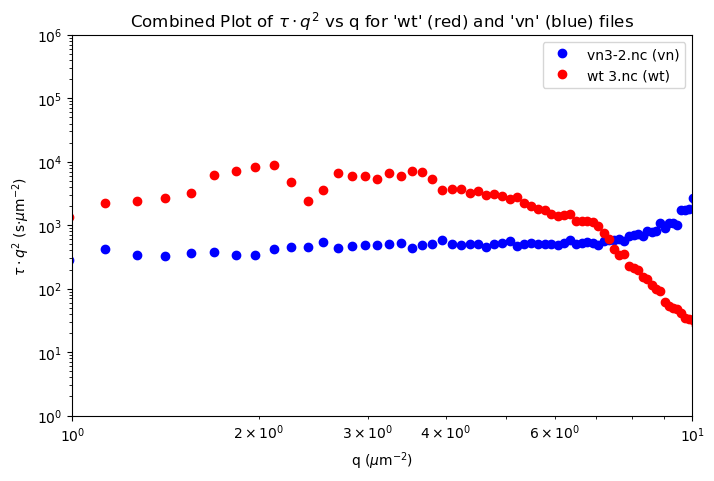

Combined plot saved as combined_tau_q_squared_vs_q.png.


In [42]:


# Create a figure for the combined plot
fig_combined, ax_combined = plt.subplots(figsize=(8, 8/1.618))

# Step 2: Loop through each .nc file in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.nc'):  # Process only .nc files
        nc_file_path = os.path.join(folder_path, filename)

        # Load the .nc file using xarray
        ddm_fit_data = xr.load_dataset(nc_file_path)

        # Extract Tau and q values where parameter == 'Tau'
        #tau = ddm_fit_data.parameters.where(ddm_fit_data.parameter == 'Tau', drop=True)
        #q_values = ddm_fit_data.q.where(ddm_fit_data.parameter == 'Tau', drop=True)

        # Extract 'Tau' (decay time) and 'q' values
        tau = ddm_fit_data.parameters.loc['Tau']
        q_values = ddm_fit_data.q


        # Check if 'index' exists in the dataset, and only drop if it does
        if 'index' in tau.coords:
            tau = tau.drop('index')
        if 'index' in q_values.coords:
            q_values = q_values.drop('index')
        if 'index' in stretchexp.coords:
            stretchexp = stretchexp.drop('index')


        # Drop the 'index' coordinate (if present)
        #tau = tau.drop('index')
        #q_values = q_values.drop('index')

        # Filter out any NaN or Inf values from the data
        valid_indices = np.isfinite(tau) & np.isfinite(q_values)
        tau = tau[valid_indices]
        q_values = q_values[valid_indices]

        # Calculate tau * q^2
        tau_q_squared = tau * q_values**2

        # Determine color based on filename
        if 'wt' in filename:
            color = 'red'
            label = f'{filename} (wt)'
        elif 'vn' in filename:
            color = 'blue'
            label = f'{filename} (vn)'
        else:
            color = 'black'
            label = filename

        # Add data to the combined plot
        ax_combined.loglog(q_values, tau_q_squared, 'o', label=label, color=color)

        # Plotting tau * q^2 vs q for each individual file (optional, if you want to save individual plots)
        fig, ax = plt.subplots(figsize=(8, 8/1.618))
        ax.loglog(q_values, tau_q_squared, 'ro', label=r"$\tau \cdot q^2$")
        ax.legend()

        # Customize the individual plot
        ax.set_xlim(1, 10)
        ax.set_ylim(1, 1e6)
        ax.set_xlabel("q ($\mu$m$^{-2}$)")
        ax.set_ylabel(r"$\tau \cdot q^2$ (s·$\mu$m$^{-2}$)")
        plt.title(rf"Plot of $\tau \cdot q^2$ vs q for {filename}")

        # Save the individual plot
        plot_filename = f"{filename}_tau_q_squared_vs_q.png"
        plt.savefig(os.path.join(folder_path, plot_filename), dpi=300)
        plt.close()

        # Save the data as a CSV file
        df = pd.DataFrame({
            'q': q_values,
            'tau': tau,
            'tau_q_squared': tau_q_squared
        })

        # Save the dataframe to a CSV file
        csv_filename = f"{filename}_tau_q_squared_data.csv"
        df.to_csv(os.path.join(folder_path, csv_filename), index=False)

        print(f"Data saved to {csv_filename} and plot saved as {plot_filename} for file {filename}.")

# Customize the combined plot
ax_combined.set_xlim(1, 10)
ax_combined.set_ylim(1, 1e6)
ax_combined.set_xlabel("q ($\mu$m$^{-2}$)")
ax_combined.set_ylabel(r"$\tau \cdot q^2$ (s·$\mu$m$^{-2}$)")
plt.title(r"Combined Plot of $\tau \cdot q^2$ vs q for 'wt' (red) and 'vn' (blue) files")
ax_combined.legend(loc='best')

# Save the combined plot
combined_plot_filename = "combined_tau_q_squared_vs_q.png"
plt.savefig(os.path.join(folder_path, combined_plot_filename), dpi=300)
plt.show()

print(f"Combined plot saved as {combined_plot_filename}.")

